In [ ]:
#########################################################################
# # ! Moon Topographic-Gravitational-Potential Computation: PH vs SH
#########################################################################
# %% 
# # ! Setup
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pyshtools as pysh
import pyvista as pv
import time
from datetime import datetime
from gravity_forward_numba import *

In [ ]:
# # ! Start time
print("=" * 80)
print(f"Start time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

Start time: [2026-05-20 12:49:24]


In [ ]:
# # ! Functions
def Shgrid2Mesh(shgrid):
    mesh = pv.Sphere(radius=1.0, center=(0.0, 0.0, 0.0),
                     theta_resolution=shgrid.nlon-1,
                     phi_resolution=shgrid.nlat)
    [LON, LAT] = np.meshgrid(shgrid.lons(), shgrid.lats())
    R = shgrid.data
    X = R * np.cos(np.deg2rad(LAT)) * np.cos(np.deg2rad(LON))
    Y = R * np.cos(np.deg2rad(LAT)) * np.sin(np.deg2rad(LON))
    Z = R * np.sin(np.deg2rad(LAT))
    # north pole, south pole, and regular points
    pts_x = np.hstack([X[0,0], X[-1,0], X[1:-1,:-1].flatten(order='F')]) 
    pts_y = np.hstack([Y[0,0], Y[-1,0], Y[1:-1,:-1].flatten(order='F')])
    pts_z = np.hstack([Z[0,0], Z[-1,0], Z[1:-1,:-1].flatten(order='F')])
    pts_r = np.sqrt(pts_x**2 + pts_y**2 + pts_z**2)
    Verts = np.column_stack((pts_x, pts_y, pts_z))
    mesh.points = Verts
    return mesh, pts_r

In [ ]:
# # ! Load Top-N largest |gD| errors
df_errors = pd.read_csv('output/Moon_gNED_errors.csv')
err_lat_rad = np.deg2rad(df_errors['Lat'].values)
err_lon_rad = np.deg2rad(df_errors['Lon'].values)
gN_SH = df_errors['gN_SH'].values
gE_SH = df_errors['gE_SH'].values
gD_SH = df_errors['gD_SH'].values
df_gN_SH_PHs = df_errors[['Lat', 'Lon', 'Topo_m', 'gN_SH']].copy()
df_gE_SH_PHs = df_errors[['Lat', 'Lon', 'Topo_m', 'gE_SH']].copy()
df_gD_SH_PHs = df_errors[['Lat', 'Lon', 'Topo_m', 'gD_SH']].copy()

In [ ]:
# # ! Computation of TGP: Polyhedron
#### * Shape of Moon
lmax_shp = 359
clm_shp_moon = \
    pysh.SHCoeffs.from_file(f'input/Moon_shape_719.sh', 
                            lmax=lmax_shp, 
                            name='LOLA_shape (Moon)',
                            units='m', format='bshc')
r_itfc_km = clm_shp_moon.coeffs[0,0,0] / 1.e3
#### * Calculation points
rho0 = 2560.0 # kg/m^3
r_calc_km = 1748000.0 / 1.e3
xps = r_calc_km * np.cos(err_lat_rad) * np.cos(err_lon_rad)
yps = r_calc_km * np.cos(err_lat_rad) * np.sin(err_lon_rad)
zps = r_calc_km * np.sin(err_lat_rad)
#### * Computation of TGP
IN_RES = np.array([15.0, 10.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0]) / 60.0 # degree
for in_res in IN_RES:
    nc_Topo = f'output/moon_topo_Lshp{lmax_shp}_{int(60*in_res)}arcmin.nc'
    grd_topo = pysh.SHGrid.from_netcdf(nc_Topo)
    grd_shp = grd_topo + r_itfc_km
    mesh_shp, _ = Shgrid2Mesh(grd_shp)
    Verts = mesh_shp.points
    Faces = mesh_shp.regular_faces
    del mesh_shp
    P = np.column_stack((xps, yps, zps))
    t0 = time.time()
    vgt_PH = WerSch_numba_v2(P, Verts, Faces, rho0)
    tc = time.time() - t0
    print("Computation info: \n"
         f"Number of computation points: {P.shape[0]} \n"
         "Polyhedron geometry: \n"
         f"Input geographic resolution: {int(60*in_res):2d}-arcmin \n"
         f"Number of faces: {Faces.shape[0]} \n"
         f"Number of vertices: {Verts.shape[0]} \n"
         f"Time cost : {tc:8.3f} sec = {tc/60:.3f} min = {tc/(60*60):.3f} hr\n")
    #### * TGP = Shape model gravity - Sphere (r=r_itfc) gravity
    vgt_SP = gsphere(xps, yps, zps, 0, 0, 0, r_itfc_km, rho0)
    vgt_TP = tuple(g_PH - g_SP for g_PH, g_SP in zip(vgt_PH, vgt_SP))
    V, gx, gy, gz, Txx, Txy, Txz, Tyy, Tyz, Tzz = vgt_TP
    gN, gE, gD, TNN, TNE, TND, TEE, TED, TDD = \
        rotate_vec_ten_ecef2ned(err_lon_rad, err_lat_rad, 
                                gx, gy, gz, 
                                Txx, Txy, Txz, Tyy, Tyz, Tzz)
    df_gN_SH_PHs[f'e_gN_PH_{int(60*in_res)}'] = np.round(gN - gN_SH, 4)
    df_gE_SH_PHs[f'e_gE_PH_{int(60*in_res)}'] = np.round(gE - gE_SH, 4)
    df_gD_SH_PHs[f'e_gD_PH_{int(60*in_res)}'] = np.round(gD - gD_SH, 4)

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input geographic resolution: 15-arcmin 
Number of faces: 2070720 
Number of vertices: 1035362 
Time cost :    1.382 sec = 0.023 min = 0.000 hr

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input geographic resolution: 10-arcmin 
Number of faces: 4661280 
Number of vertices: 2330642 
Time cost :    0.361 sec = 0.006 min = 0.000 hr

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input geographic resolution:  6-arcmin 
Number of faces: 12952800 
Number of vertices: 6476402 
Time cost :    1.068 sec = 0.018 min = 0.000 hr

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input geographic resolution:  5-arcmin 
Number of faces: 18653760 
Number of vertices: 9326882 
Time cost :    1.515 sec = 0.025 min = 0.000 hr

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input geographic resolution:  4-arcmin 
Number 

--------------------------------------------------------------------------------
Absolute errors of (gN, gE, gD) in mGal for different resolutions:
--------------------------------------------------------------------------------
   e_gN_PH_15  e_gN_PH_10  e_gN_PH_6  e_gN_PH_5  e_gN_PH_4  e_gN_PH_3  \
0      3.0860      1.2328     0.2472     0.0772     0.0626     0.1703   
1      0.2692      0.0840     0.0236     0.0156     0.0096     0.0052   
2      0.1731      0.0472     0.0043     0.0105     0.0149     0.0179   
3      0.9294      0.4097     0.1455     0.0990     0.0606     0.0304   
4      2.2514      0.9973     0.3458     0.2341     0.1427     0.0715   
5      2.2795      0.9987     0.3387     0.2258     0.1334     0.0614   
6      1.1558      0.5107     0.1841     0.1271     0.0802     0.0437   
7      0.1640      0.0658     0.0218     0.0138     0.0072     0.0020   
8      0.8167      0.3522     0.1246     0.0862     0.0550     0.0308   
9      1.6309      0.7561     0.2794     

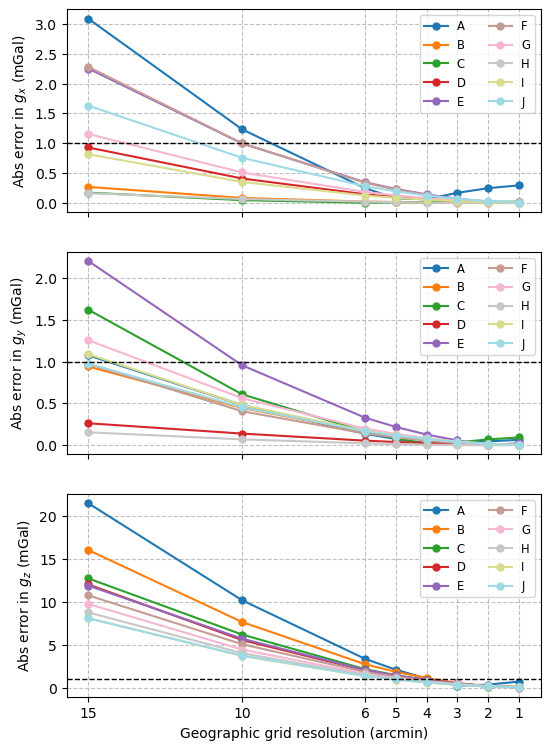

In [ ]:
# # ! Plot error reduction vs. resolution
#### * Absolute errors in mGal
df_err_gN = df_gN_SH_PHs.iloc[:, 4:].abs()
df_err_gE = df_gE_SH_PHs.iloc[:, 4:].abs()
df_err_gD = df_gD_SH_PHs.iloc[:, 4:].abs()
print('-' * 80)
print("Absolute errors of (gN, gE, gD) in mGal for different resolutions:")
print('-' * 80)
for df in [df_err_gN, df_err_gE, df_err_gD]: print(df, '=' * 80, sep='\n')
#### * Plotting
nP = len(df_err_gD)
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
colors = plt.cm.tab20(np.linspace(0, 1, min(nP, 20)))
err_txt = ['A','B','C','D','E','F','G','H','I','J']
for df, ax, comp in zip([df_err_gN, df_err_gE, df_err_gD], axes, 
                        ['g_x', 'g_y', 'g_z']):
    for i in range(nP):
        color = colors[i % len(colors)]
        ax.plot(60 * IN_RES, df.iloc[i].values,
                marker='o', ms=5, color=color, label=f'{err_txt[i]}')
    ax.set_ylabel(f'Abs error in ${comp}$ (mGal)')
    ax.set_xticks(60 * IN_RES)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.0, alpha=1.0)
    ax.grid(which='both', linestyle='--', alpha=0.8)
    ax.invert_xaxis()
    ax.legend(loc='upper right', fontsize='small', ncol=2)
axes[-1].set_xlabel('Geographic grid resolution (arcmin)')
plt.tight_layout(pad=2.5)
# plt.savefig("Moon_TopoGxyz_PH_vs_SH_3.png", 
#             dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# # ! End time
print("=" * 80)
print(f"End time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

End time: [2026-05-20 12:51:41]
